In [1]:
import os
import sys

# Add the parent directory to sys.path
project_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_path not in sys.path:
    sys.path.append(project_path)

import seaborn as sns

import globals as gl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import warnings
import pandas as pd
warnings.filterwarnings("ignore")
from myplot import make_yref
import rsatoolbox as rsa
import numpy as np

from Rsa import calc_G_cosine

import nitools as nt
import nibabel as nb

sys.path.append('/Users/mnlmrc/Documents/GitHub')
sys.path.append('/Users/mnlmrc/Documents/GitHub/Functional_Fusion')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub/Functional_Fusion')

from Functional_Fusion.dataset import reliability_within_subj
import surfAnalysisPy as surf

plt.close('all')
plt.style.use('default')


Base directory found: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/
Base directory: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/


# **Behaviour**

## **Force response during training**

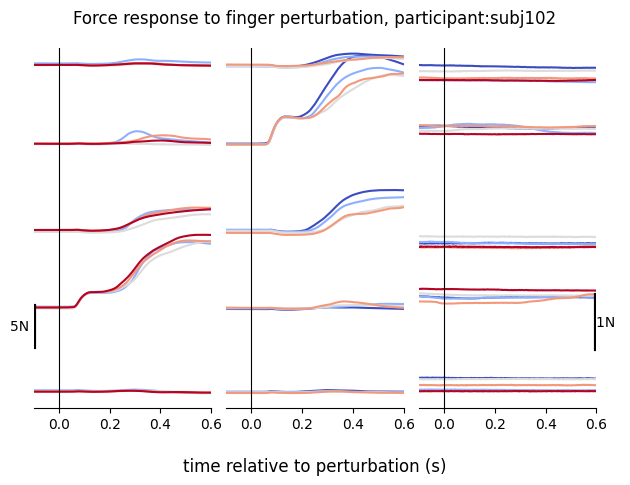

In [2]:


experiment = 'smp2'
session = 'training'
participant_id = 'subj102'
sn = int(''.join([c for c in participant_id if c.isdigit()]))
vsep_go = 10
vsep_nogo = 1.5

participants = pd.read_csv(os.path.join(gl.baseDir, experiment, 'participants.tsv'), sep='\t')

dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.trainDir, participant_id, f'{experiment}_{sn}.dat'), sep='\t')

npz = np.load(os.path.join(gl.baseDir, experiment, gl.trainDir, participant_id, f'{experiment}_{sn}.npz'))
force = npz['data_array']

fig, axs = plt.subplots(ncols=3, sharex=True)

cmap = plt.get_cmap("coolwarm")
colors = [cmap(i) for i in np.linspace(0, 1, force.shape[1])]

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for c, cue in enumerate(gl.cue_code):
    for sf, stimF in enumerate(gl.stimFinger_code):
        for f in range(force.shape[1]):
            force_tmp = force[(dat.cue == cue) & (dat.stimFinger == stimF) & (dat.GoNogo == 'go'), f].mean(axis=0, keepdims=True).squeeze()
            axs[sf].plot(tAx, force_tmp + f * vsep_go, color=colors[c])
            
axs[0].spines[['top', 'right', 'left']].set_visible(False)
axs[0].axvline(0, ls='-', color='k', lw=.8)
axs[0].set_yticks([])

axs[1].spines[['top', 'right', 'left']].set_visible(False)
axs[1].axvline(0, ls='-', color='k', lw=.8)
axs[1].set_yticks([])

axs[0].set_xlim([-.1, .6])
axs[0].set_ylim([-2, 42])
axs[1].set_ylim([-2, 42])

for c, cue in enumerate(gl.cue_code):
    for f in range(force.shape[1]):
        force_tmp = force[(dat.cue == cue) & (dat.GoNogo == 'nogo'), f].mean(axis=0, keepdims=True).squeeze()
        axs[2].plot(tAx, force_tmp + f * vsep_nogo, color=colors[c])

axs[2].spines[['top', 'right', 'left']].set_visible(False)
axs[2].axvline(0, ls='-', color='k', lw=.8)
axs[2].set_yticks([])

make_yref(axs[0], reference_length=5, pos='left')
make_yref(axs[2], reference_length=1, pos='right')
            
fig.supxlabel('time relative to perturbation (s)')

fig.suptitle(f'Force response to finger perturbation, participant:{participant_id}')

fig.tight_layout()



## **Force response during scanning**

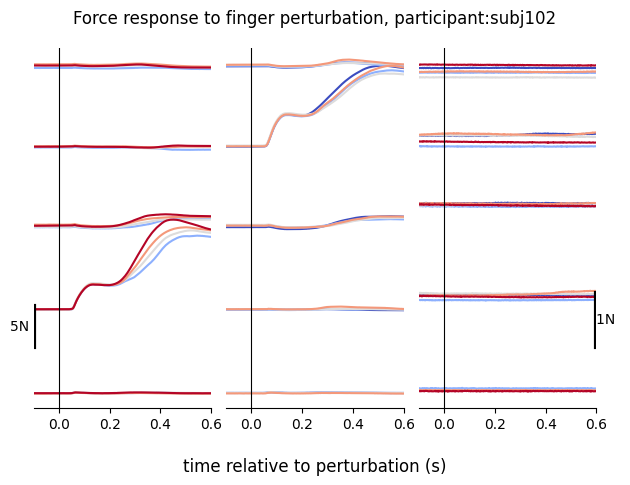

In [17]:
experiment = 'smp2'
participant_id = 'subj102'
sn = int(''.join([c for c in participant_id if c.isdigit()]))
vsep_go = 10
vsep_nogo = 1.5

participants = pd.read_csv(os.path.join(gl.baseDir, experiment, 'participants.tsv'), sep='\t')

dat = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, participant_id, f'{experiment}_{sn}.dat'), sep='\t')

npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, participant_id, f'{experiment}_{sn}_force_segmented.npz'))
force = npz['data_array']

fig, axs = plt.subplots(ncols=3, sharex=True)

cmap = plt.get_cmap("coolwarm")
colors = [cmap(i) for i in np.linspace(0, 1, force.shape[1])]

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for c, cue in enumerate(gl.cue_code):
    for sf, stimF in enumerate(gl.stimFinger_code):
        for f in range(force.shape[1]):
            force_tmp = force[(dat.cue == cue) & (dat.stimFinger == stimF) & (dat.GoNogo == 'go'), f].mean(axis=0, keepdims=True).squeeze()
            axs[sf].plot(tAx, force_tmp + f * vsep_go, color=colors[c])
            
axs[0].spines[['top', 'right', 'left']].set_visible(False)
axs[0].axvline(0, ls='-', color='k', lw=.8)
axs[0].set_yticks([])

axs[1].spines[['top', 'right', 'left']].set_visible(False)
axs[1].axvline(0, ls='-', color='k', lw=.8)
axs[1].set_yticks([])

axs[0].set_xlim([-.1, .6])
axs[0].set_ylim([-2, 42])
axs[1].set_ylim([-2, 42])

for c, cue in enumerate(gl.cue_code):
    for f in range(force.shape[1]):
        force_tmp = force[(dat.cue == cue) & (dat.GoNogo == 'nogo'), f].mean(axis=0, keepdims=True).squeeze()
        axs[2].plot(tAx, force_tmp + f * vsep_nogo, color=colors[c])

axs[2].spines[['top', 'right', 'left']].set_visible(False)
axs[2].axvline(0, ls='-', color='k', lw=.8)
axs[2].set_yticks([])

make_yref(axs[0], reference_length=5, pos='left')
make_yref(axs[2], reference_length=1, pos='right')
            
fig.supxlabel('time relative to perturbation (s)')

fig.suptitle(f'Force response to finger perturbation, participant:{participant_id}')

fig.tight_layout()

# fig.savefig(os.path.join(gl.baseDir, experiment, 'figures', 'force_response_training.svg'))


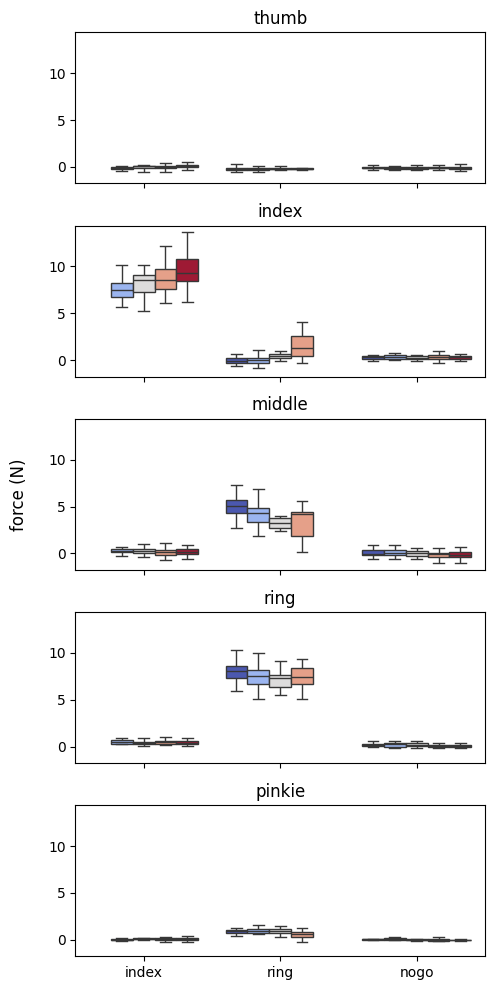

In [5]:
experiment = 'smp2'
sn = 103

force_df = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
force_df['cue'] = force_df['cue'].map(gl.cue_mapping)
force_df['stimFinger'] = force_df['stimFinger'].map(gl.stimFinger_mapping)

fingers = ['thumb', 'index', 'middle', 'ring', 'pinkie']

fig, axs = plt.subplots(len(fingers), sharex=True, sharey=True, figsize=(5, 10))

cmap = plt.get_cmap("coolwarm")
colors = [cmap(i) for i in np.linspace(0, 1, 5)]

for f, finger in enumerate(fingers):

    sns.boxplot(x='stimFinger', y=finger, ax=axs[f], hue='cue',data=force_df, hue_order=list(gl.cue_mapping.values()), order=list(gl.stimFinger_mapping.values()), showfliers=False, palette=colors, legend=False)
    
    axs[f].set_xlabel('')
    axs[f].set_ylabel('')
    axs[f].set_title(finger)
    
fig.supylabel('force (N)')
fig.tight_layout()

# **HRF** 

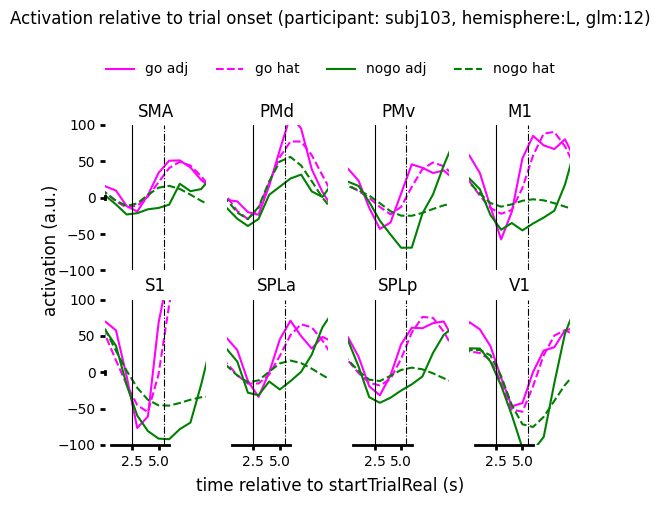

In [6]:
import scipy

experiment = 'smp2'
Hem = 'L'
roi = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
r = 0
glm = 12
participant_id='subj103'

mat = scipy.io.loadmat(os.path.join(gl.baseDir, experiment, gl.roiDir, participant_id, f'hrf_glm{glm}.mat'))
T = mat['T'][0, 0]
T_fields = T.dtype.names
T_dict = {field: T[field] for field in T_fields}

tAx = np.linspace(-10, 10, 21)

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(6, 5))
for i in range(2):
    for j in range(4):
        # fig, axs[i, j] = main('PLOT:hrf_roi', experiment, participant_id=participant_id, glm=glm, roi=roi[r], Hem=Hem, fig=fig, axs=axs[i, j])

        y_adj_go = np.nanmean(T_dict['y_adj'][((T_dict['name'] == roi[r]) & (T_dict['GoNogo'] == 'go') & (T_dict['hem'] == Hem)).flatten()], axis=0)
        y_hat_go = np.nanmean(T_dict['y_hat'][((T_dict['name'] == roi[r]) & (T_dict['GoNogo'] == 'go') &  (T_dict['hem'] == Hem)).flatten()], axis=0)
        y_adj_nogo = np.nanmean(T_dict['y_adj'][((T_dict['name'] == roi[r]) & (T_dict['GoNogo'] == 'nogo') & (T_dict['hem'] == Hem)).flatten()], axis=0)
        y_hat_nogo = np.nanmean(T_dict['y_hat'][((T_dict['name'] == roi[r]) & (T_dict['GoNogo'] == 'nogo') &   (T_dict['hem'] == Hem)).flatten()], axis=0)
        # y_raw_go = np.nanmean(T_dict['y_raw'][((T_dict['name'] == roi[r]) & (T_dict['eventname'] == 'go') & (T_dict['hem'] == Hem)).flatten()], axis=0)
        # y_raw_nogo = np.nanmean(T_dict['y_raw'][((T_dict['name'] == roi[r]) & (T_dict['eventname'] == 'nogo') & (T_dict['hem'] == Hem)).flatten()], axis=0)

        axs[i, j].plot(tAx, y_adj_go, color='magenta', label='go adj', ls='-')
        # axs[i, j].plot(tAx, y_raw_go - y_raw_go.mean(), color='magenta', label='go raw', ls='-', alpha=0.3)
        axs[i, j].plot(tAx, y_hat_go, color='magenta', label='go hat', ls='--')
        # axs[i, j].plot(tAx, y_raw_nogo - y_raw_nogo.mean(), color='green', label='nogo raw', ls='-', alpha=0.3)
        axs[i, j].plot(tAx, y_adj_nogo, color='green', label='nogo adj', ls='-')
        axs[i, j].plot(tAx, y_hat_nogo, color='green', label='nogo hat', ls='--')

        # axs[i, j].axvline(0, color='k', ls='--', lw=.8)
        axs[i, j].axvline(2.5, color='k', ls='-', lw=.8)
        axs[i, j].axvline(5.5, color='k', ls='-.', lw=.8)
        axs[i, j].set_title(roi[r])
        axs[i, j].set_xlim([0, 9.5])
        # axs[i, j].set_ylim([0, 9.5])
        axs[i, j].set_xticks([ 2.5, 5])

        # Remove unnecessary spines
        axs[i, j].spines['top'].set_visible(False)
        axs[i, j].spines['right'].set_visible(False)

        # Hide left and bottom spines based on row/column
        if i == 0:
            axs[i, j].spines['bottom'].set_visible(False)  # First row, hide bottom spine
        if j > 0:
            axs[i, j].spines['left'].set_visible(False)  # Hide left spines except first column
        
        # Hide ticks for non-left columns and first row
        if j > 0:
            axs[i, j].tick_params(axis='y', left=False)
        if i == 0:
            axs[i, j].tick_params(axis='x', bottom=False)

        r += 1

# Ensure left spines and ticks are visible for the first column
for i in range(2):
    axs[i, 0].spines['left'].set_visible(True)  # Show left spine for first column
    axs[i, 0].spines['left'].set_linewidth(2)  # Set left spine width for first column
    axs[i, 0].set_ylim([-100, 100])
    axs[i, 0].spines['left'].set_bounds([-2, 2])
    axs[i, 0].tick_params(axis='y', width=2)  # Show y-axis ticks for the first column

# Ensure bottom spines and ticks are visible for the second row
for j in range(4):
    axs[1, j].spines['bottom'].set_visible(True)  # Show bottom spine for second row
    axs[1, j].spines['bottom'].set_linewidth(2)  # Set bottom spine width for second row
    axs[1, j].spines['bottom'].set_bounds([.5, 6])
    axs[1, j].tick_params(axis='x', width=2)  # Show x-axis ticks for second row

# Legend and labels
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, .9), frameon=False)
fig.supylabel('activation (a.u.)')
fig.supxlabel('time relative to startTrialReal (s)')
fig.suptitle(f'Activation relative to trial onset (participant: {participant_id}, hemisphere:{Hem}, glm:{glm})')

fig.subplots_adjust(top=0.75)


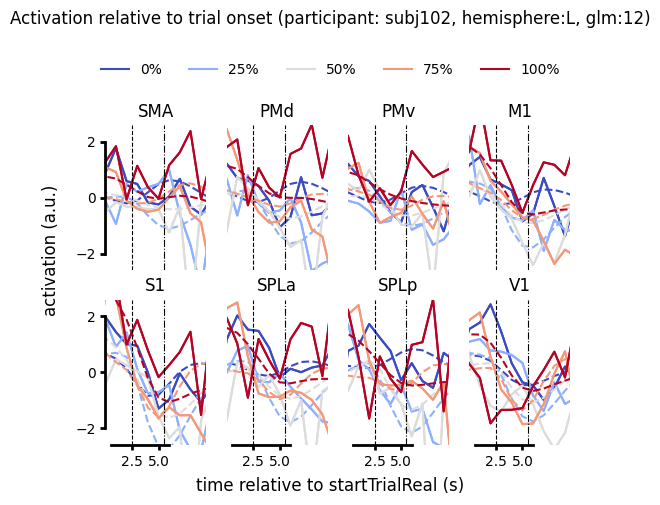

In [5]:
import scipy

experiment = 'smp2'
Hem = 'L'
roi = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
r = 0
glm = 12
participant_id='subj102'

mat = scipy.io.loadmat(os.path.join(gl.baseDir, experiment, gl.roiDir, participant_id, f'hrf_glm{glm}.mat'))
T = mat['T'][0, 0]
T_fields = T.dtype.names
T_dict = {field: T[field] for field in T_fields}

tAx = np.linspace(-10, 10, 21)

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(6, 5))

cmap = plt.get_cmap("coolwarm")
colors = [cmap(i) for i in np.linspace(0, 1, force.shape[1])]
for i in range(2):
    for j in range(4):
        for c, cue in enumerate(gl.cue_code):

            y_adj = np.nanmean(T_dict['y_adj'][((T_dict['name'] == roi[r]) & (T_dict['GoNogo'] == 'nogo') & (T_dict['hem'] == Hem) & (T_dict['cue'] == cue)).flatten()], axis=0)
            y_hat = np.nanmean(T_dict['y_hat'][((T_dict['name'] == roi[r]) & (T_dict['GoNogo'] == 'nogo') & (T_dict['hem'] == Hem) & (T_dict['cue'] == cue)).flatten()], axis=0)

            axs[i, j].plot(tAx, y_hat, color=colors[c], ls='--')

            axs[i, j].plot(tAx, y_adj, color=colors[c], label=gl.cue_mapping[cue], ls='-')
            axs[i, j].plot(tAx, y_adj, color=colors[c], label=gl.cue_mapping[cue], ls='-')

        # axs[i, j].axvline(.5, color='k', ls='-', lw=.8)
        axs[i, j].axvline(2.5, color='k', ls='--', lw=.8)
        axs[i, j].axvline(5.5, color='k', ls='-.', lw=.8)
        axs[i, j].set_title(roi[r])
        axs[i, j].set_xlim([0, 9.5])
        axs[i, j].set_xticks([ 2.5, 5])

        # Remove unnecessary spines
        axs[i, j].spines['top'].set_visible(False)
        axs[i, j].spines['right'].set_visible(False)

        # Hide left and bottom spines based on row/column
        if i == 0:
            axs[i, j].spines['bottom'].set_visible(False)  # First row, hide bottom spine
        if j > 0:
            axs[i, j].spines['left'].set_visible(False)  # Hide left spines except first column

        # Hide ticks for non-left columns and first row
        if j > 0:
            axs[i, j].tick_params(axis='y', left=False)
        if i == 0:
            axs[i, j].tick_params(axis='x', bottom=False)

        r += 1

# Ensure left spines and ticks are visible for the first column
for i in range(2):
    axs[i, 0].spines['left'].set_visible(True)  # Show left spine for first column
    axs[i, 0].spines['left'].set_linewidth(2)  # Set left spine width for first column
    axs[i, 0].set_ylim([-2.6, 2.6])
    axs[i, 0].spines['left'].set_bounds([-2, 2])
    axs[i, 0].tick_params(axis='y', width=2)  # Show y-axis ticks for the first column

# Ensure bottom spines and ticks are visible for the second row
for j in range(4):
    axs[1, j].spines['bottom'].set_visible(True)  # Show bottom spine for second row
    axs[1, j].spines['bottom'].set_linewidth(2)  # Set bottom spine width for second row
    axs[1, j].spines['bottom'].set_bounds([.5, 6])
    axs[1, j].tick_params(axis='x', width=2)  # Show x-axis ticks for second row

# Legend and labels
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles[::2], labels[::2], loc='upper center', ncol=5, bbox_to_anchor=(0.5, .9), frameon=False)
fig.supylabel('activation (a.u.)')
fig.supxlabel('time relative to startTrialReal (s)')
fig.suptitle(f'Activation relative to trial onset (participant: {participant_id}, hemisphere:{Hem}, glm:{glm})')

fig.subplots_adjust(top=0.75)

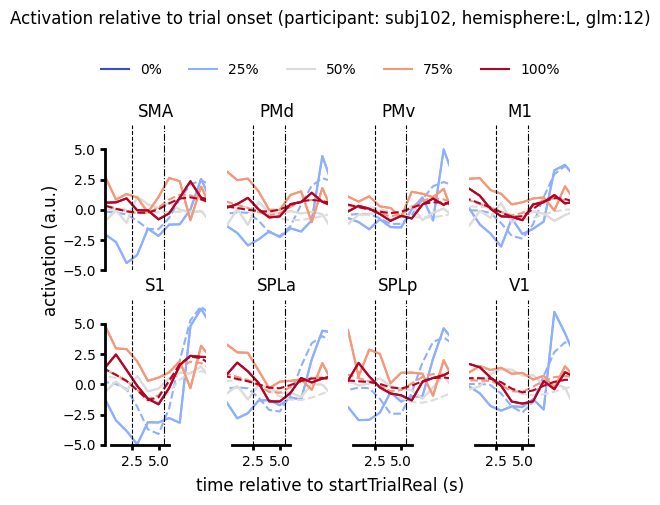

In [6]:
import scipy

experiment = 'smp2'
Hem = 'L'
roi = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
r = 0
glm = 12
participant_id='subj102'

stimFinger = 91999

mat = scipy.io.loadmat(os.path.join(gl.baseDir, experiment, gl.roiDir, participant_id, f'hrf_glm{glm}.mat'))
T = mat['T'][0, 0]
T_fields = T.dtype.names
T_dict = {field: T[field] for field in T_fields}

tAx = np.linspace(-10, 10, 21)

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(6, 5))

cmap = plt.get_cmap("coolwarm")
colors = [cmap(i) for i in np.linspace(0, 1, force.shape[1])]
for i in range(2):
    for j in range(4):
        for c, cue in enumerate(gl.cue_code):

            y_adj = np.nanmean(T_dict['y_adj'][((T_dict['name'] == roi[r]) & (T_dict['stimFinger'] == stimFinger) & (T_dict['GoNogo'] == 'go') & (T_dict['hem'] == Hem) & (T_dict['cue'] == cue)).flatten()], axis=0)
            y_hat = np.nanmean(T_dict['y_hat'][((T_dict['name'] == roi[r]) & (T_dict['stimFinger'] == stimFinger) & (T_dict['hem'] == Hem) & (T_dict['cue'] == cue)).flatten()], axis=0)

            axs[i, j].plot(tAx, y_hat, color=colors[c], ls='--')

            axs[i, j].plot(tAx, y_adj, color=colors[c], label=gl.cue_mapping[cue], ls='-')
            axs[i, j].plot(tAx, y_adj, color=colors[c], label=gl.cue_mapping[cue], ls='-')

        # axs[i, j].axvline(.5, color='k', ls='-', lw=.8)
        axs[i, j].axvline(2.5, color='k', ls='--', lw=.8)
        axs[i, j].axvline(5.5, color='k', ls='-.', lw=.8)
        axs[i, j].set_title(roi[r])
        axs[i, j].set_xlim([0, 9.5])
        axs[i, j].set_xticks([ 2.5, 5])

        # Remove unnecessary spines
        axs[i, j].spines['top'].set_visible(False)
        axs[i, j].spines['right'].set_visible(False)

        # Hide left and bottom spines based on row/column
        if i == 0:
            axs[i, j].spines['bottom'].set_visible(False)  # First row, hide bottom spine
        if j > 0:
            axs[i, j].spines['left'].set_visible(False)  # Hide left spines except first column

        # Hide ticks for non-left columns and first row
        if j > 0:
            axs[i, j].tick_params(axis='y', left=False)
        if i == 0:
            axs[i, j].tick_params(axis='x', bottom=False)

        r += 1

# Ensure left spines and ticks are visible for the first column
for i in range(2):
    axs[i, 0].spines['left'].set_visible(True)  # Show left spine for first column
    axs[i, 0].spines['left'].set_linewidth(2)  # Set left spine width for first column
    axs[i, 0].set_ylim([-5, 7])
    axs[i, 0].spines['left'].set_bounds([-5, 5])
    axs[i, 0].tick_params(axis='y', width=2)  # Show y-axis ticks for the first column

# Ensure bottom spines and ticks are visible for the second row
for j in range(4):
    axs[1, j].spines['bottom'].set_visible(True)  # Show bottom spine for second row
    axs[1, j].spines['bottom'].set_linewidth(2)  # Set bottom spine width for second row
    axs[1, j].spines['bottom'].set_bounds([.5, 6])
    axs[1, j].tick_params(axis='x', width=2)  # Show x-axis ticks for second row

# Legend and labels
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles[::2], labels[::2], loc='upper center', ncol=5, bbox_to_anchor=(0.5, .9), frameon=False)
fig.supylabel('activation (a.u.)')
fig.supxlabel('time relative to startTrialReal (s)')
fig.suptitle(f'Activation relative to trial onset (participant: {participant_id}, hemisphere:{Hem}, glm:{glm})')

fig.subplots_adjust(top=0.75)

# **Activity**

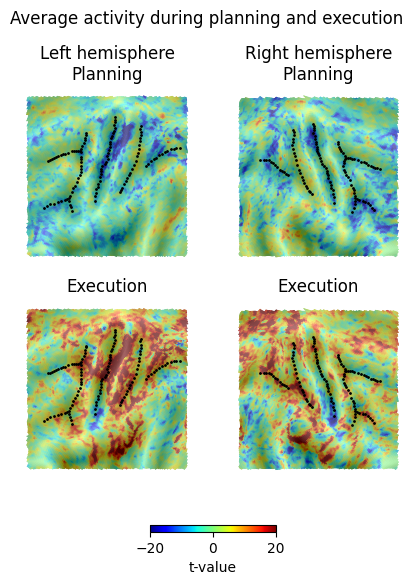

In [20]:
glm = 12
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(5, 6))
sn = 102
experiment = 'smp2'
dtype = 'con'

vmin, vmax = -20, 20

xlim = {
    'L': [-80, 120],
    'R': [-120, 80],
}
ylim = {
    'L': [-50, 150],
    'R':[-60, 140]
}

for H, Hem in enumerate(['L', 'R']):

    data = os.path.join(gl.baseDir, experiment, gl.wbDir, f'subj{sn}', f'glm{glm}.{dtype}.{Hem}.func.gii')
    
    D = nb.load(data)
    darray = nt.get_gifti_data_matrix(D)
    
    col_names = nt.get_gifti_column_names(D)
    
    plan_col_names = [f'con_{col}.nii' for col in ['0%', '25%', '50%', '75%', '100%']]
    exec_col_names = [f'con_{col}.nii' for col in ['0%,index', '25%,index', '50%,index', '75%,index', '100%,index', '0%,ring', '25%,ring', '50%,ring', '75%,ring', '100%,ring']]
    
    im = np.array([x in plan_col_names for x in col_names])
    darray_avg = np.array(darray[:, im]).mean(axis=1)
    plt.sca(axs[0, H])
    surf.plot.plotmap(darray_avg, f'fs32k_{Hem}',
                      underlay=None,
                      borders=gl.borders[Hem],
                      cscale=[vmin, vmax],
                      cmap='jet',
                      underscale=[-1.5, 1],
                      alpha=.5,
                      new_figure=False,
                      colorbar=False,
                      frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]])
    
    im = np.array([x in exec_col_names for x in col_names])
    darray_avg = np.array(darray[:, im]).mean(axis=1)
    plt.sca(axs[1, H])
    surf.plot.plotmap(darray_avg, f'fs32k_{Hem}',
                      underlay=None,
                      borders=gl.borders[Hem],
                      cscale=[vmin, vmax],
                      cmap='jet',
                      underscale=[-1.5, 1],
                      alpha=.5,
                      new_figure=False,
                      colorbar=False,
                      frame=[xlim[Hem][0], xlim[Hem][1], ylim[Hem][0], ylim[Hem][1]])

# make colorbar
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap='jet')
cbar = fig.colorbar(sm, ax=[axs[1, 0], axs[1, 1]], orientation='horizontal', fraction=0.03)
cbar.set_label('t-value')

# cosmetic
axs[0, 0].set_title('Left hemisphere\nPlanning')
axs[0, 1].set_title('Right hemisphere\nPlanning')
axs[1, 0].set_title('Execution')
axs[1, 1].set_title('Execution')

fig.suptitle('Average activity during planning and execution')
fig.subplots_adjust(top=0.85, bottom=.2)


Text(0.02, 0.5, 'activation (a.u.)')

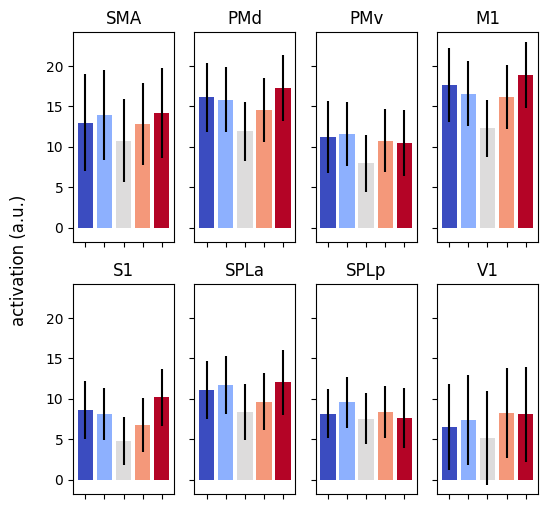

In [5]:
experiment = 'smp2'
sn = 106
glm = 12
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

reginfo = pd.read_csv(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}',
                                       f'subj{sn}_reginfo.tsv'), sep="\t")

regressors = ['0%', '25%', '50%', '75%', '100%']

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(6, 6), sharey=True, sharex=True)

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    con = np.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.{Hem}.{roi}.con.npy'))
    
    for regr, regressor in enumerate(regressors):
        con_avg = np.nanmean(con[reginfo.name.str.replace(" ", "").unique() == regressor])
        con_err = np.nanstd(con[reginfo.name.str.replace(" ", "").unique() == regressor]) / np.sqrt(len(con))
        
        axs[row, col].bar(regressor, con_avg, color=gl.colour_mapping[regressor], label=regressor, yerr=con_err,)
        
    axs[row, col].set_title(roi)
    axs[row, col].tick_params(axis='x', rotation=45)
    axs[row, col].set_xticklabels(axs[row, col].get_xticklabels(), ha='right')
    
fig.supylabel('activation (a.u.)')
    

Text(0.02, 0.5, 'activation (a.u.)')

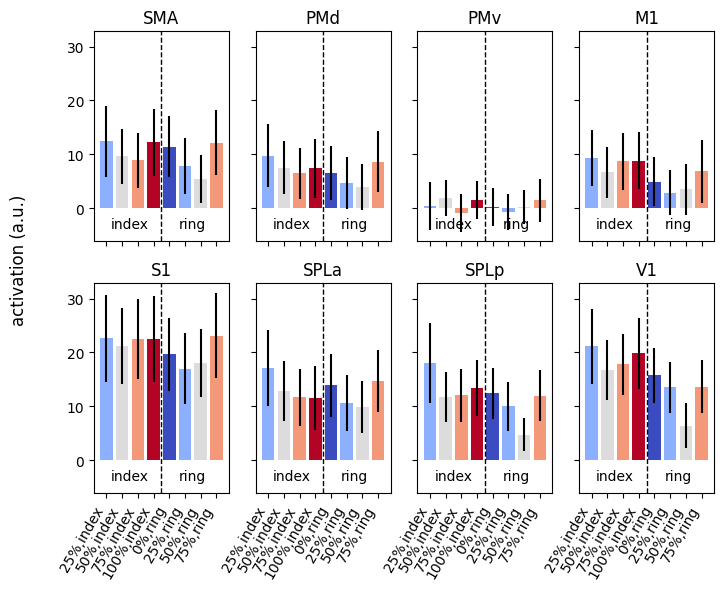

In [11]:
experiment = 'smp2'
sn = 106
glm = 12
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

reginfo = pd.read_csv(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}',
                                       f'subj{sn}_reginfo.tsv'), sep="\t")

regressors = ['25%,index', '50%,index', '75%,index', '100%,index', 
              '0%,ring', '25%,ring', '50%,ring', '75%,ring']

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(8, 6), sharey=True, sharex=True)

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    con = np.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.{Hem}.{roi}.con.npy'))
    
    for regr, regressor in enumerate(regressors):
        con_avg = con[reginfo.name.str.replace(" ", "").unique() == regressor].mean()
        con_err = con[reginfo.name.str.replace(" ", "").unique() == regressor].std() / np.sqrt(len(con))
        
        axs[row, col].bar(regressor, con_avg, color=gl.colour_mapping[regressor], label=regressor, yerr=con_err,)
    
    axs[row, col].text(1.5, -3, 'index', ha='center', va='center')
    axs[row, col].text(5.5, -3, 'ring', ha='center', va='center')
    axs[row, col].axvline(3.5, color='k', linestyle='--', linewidth=1)
    
    axs[row, col].set_title(roi)
    axs[row, col].tick_params(axis='x', rotation=60)
    axs[row, col].set_xticklabels(regressors, ha='right')
    
fig.supylabel('activation (a.u.)')

# **SNR**

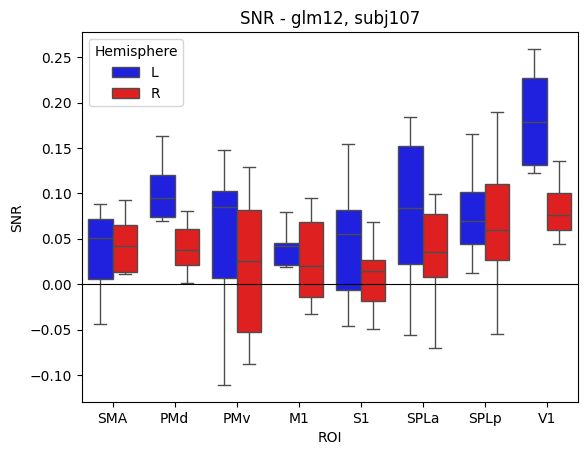

In [22]:
# Define parameters
experiment = 'smp2'
glm = 12
sn = 107

# Storage for SNR values
snr_dict = {
    'ROI': [],
    'Hemisphere': [],
    'SNR': []
}

# Iterate through hemispheres and ROIs
for Hem in ['L', 'R']:
    for roi in gl.rois['ROI']:
        # Load data
        Y = np.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.{Hem}.{roi}.beta.npy'))
        res = np.load(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}', f'ROI.{Hem}.{roi}.res.npy'))

        # Prewhitening
        Y = Y / np.sqrt(res)
        
        Y = Y.reshape(1, Y.shape[0], Y.shape[1])

        # Load partitioning and condition information
        reginfo = pd.read_csv(os.path.join(gl.baseDir, experiment, f'{gl.glmDir}{glm}', f'subj{sn}', f'subj{sn}_reginfo.tsv'), sep='\t')
        part_vec = reginfo.run
        cond_vec = reginfo.name.str.strip()
        
        snr = reliability_within_subj(Y[:, cond_vec.isin(gl.cue)], part_vec[cond_vec.isin(gl.cue)], cond_vec[cond_vec.isin(gl.cue)],
                                              voxel_wise=False,
                                              subtract_mean=True)
        # snr_avg = snr.mean()
        # snr_err = snr.std()

        # Append to data list
        for s in snr[0]:
            snr_dict['ROI'].append(roi)
            snr_dict['Hemisphere'].append(Hem)
            snr_dict['SNR'].append(s)

# Convert to DataFrame
snr_df = pd.DataFrame(snr_dict)

# Pivot Data for Faceted Plot
fig, axs = plt.subplots()
sns.boxplot(data=snr_df, y='SNR', x='ROI', hue='Hemisphere', palette={'L': 'blue', 'R': 'red'}, dodge=True, ax=axs, showfliers=False)

# Formatting
# axs.set_xlabel("region")
axs.axhline(0, color='k', lw=.8)
axs.set_ylabel("SNR")
axs.set_title(f'SNR - glm{glm}, subj{sn}')
axs.legend(title="Hemisphere")
plt.show()

# **Cue representation**

## **Planning**

Text(0.5, 0.98, 'participant:103, hemisphere:L')

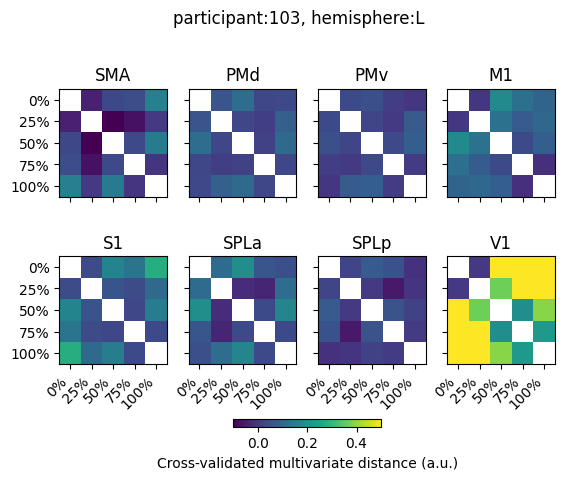

In [34]:
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, .5
sn=103
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True)

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    rdms = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
    rdms = rdms.subset_pattern(by='conds', value=['0%', '25%', '50%', '75%', '100%'])
    
    cax = rsa.vis.show_rdm_panel(
            rdms, axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
        
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'participant:{sn}, hemisphere:{Hem}')


Text(0.5, 0.98, 'participant:subj102, hemisphere:R')

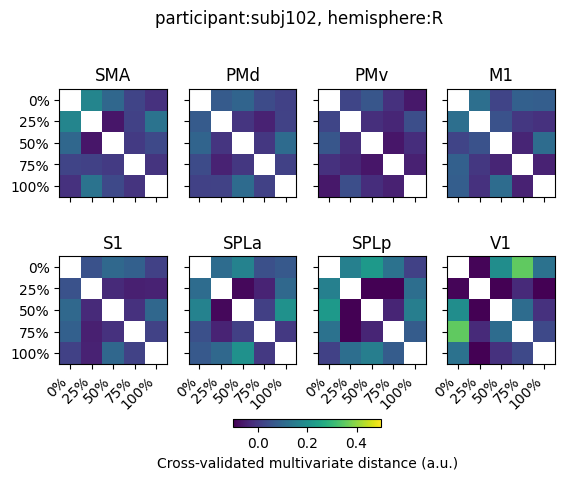

In [20]:
Hem = 'R'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, .5
sn = 102
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True)

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    print(f'plotting...glm{glm}.{Hem}.{roi[r]}.hdf5')
    
    rdms = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi[r]}.hdf5'))
    rdms = rdms.subset_pattern(by='conds', value=['0%', '25%', '50%', '75%', '100%'])
    
    cax = rsa.vis.show_rdm_panel(
            rdms, axs[i, j], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[i, j].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[i, j].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[i, j].set_yticks(axs[i, j].get_xticks())
    axs[i, j].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[i, j].set_title(roi)
    
    # axs[i, j].axhline(0, color='k', ls='-', lw=.8)
    # axs[i, j].axvline(0, color='k', ls='-', lw=.8)
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'participant:subj{sn}, hemisphere:{Hem}')


## **Execution**

plotting...glm12.L.SMA.hdf5
plotting...glm12.L.PMd.hdf5
plotting...glm12.L.PMv.hdf5
plotting...glm12.L.M1.hdf5
plotting...glm12.L.S1.hdf5
plotting...glm12.L.SPLa.hdf5
plotting...glm12.L.SPLp.hdf5
plotting...glm12.L.V1.hdf5


Text(0.5, 0.98, 'participant:subj106, hemisphere:L')

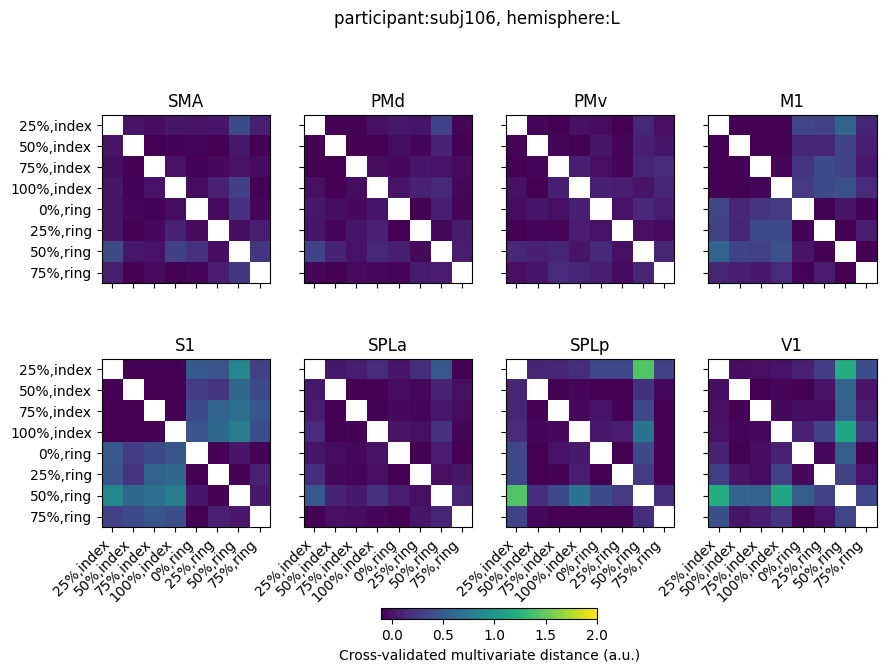

In [27]:
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
r = 0
glm = 12
vmin, vmax = -.1, 2
sn = 106

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(10, 7))

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    print(f'plotting...glm{glm}.{Hem}.{roi[r]}.hdf5')
    
    rdms = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}',f'glm{glm}.{Hem}.{roi[r]}.hdf5'))
    rdms = rdms.subset_pattern(by='conds', value=['25%,index', '50%,index', '75%,index', '100%,index',
                                                  '0%,ring', '25%,ring', '50%,ring', '75%,ring',])
    
    cax = rsa.vis.show_rdm_panel(
            rdms, axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[i, j].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
    
    # axs[i, j].axhline(0, color='k', ls='-', lw=.8)
    # axs[i, j].axvline(0, color='k', ls='-', lw=.8)
    r += 1
        
cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'participant:subj{sn}, hemisphere:{Hem}')


plotting...glm12.R.SMA.hdf5
plotting...glm12.R.PMd.hdf5
plotting...glm12.R.PMv.hdf5
plotting...glm12.R.M1.hdf5
plotting...glm12.R.S1.hdf5
plotting...glm12.R.SPLa.hdf5
plotting...glm12.R.SPLp.hdf5
plotting...glm12.R.V1.hdf5


NameError: name 'participant_id' is not defined

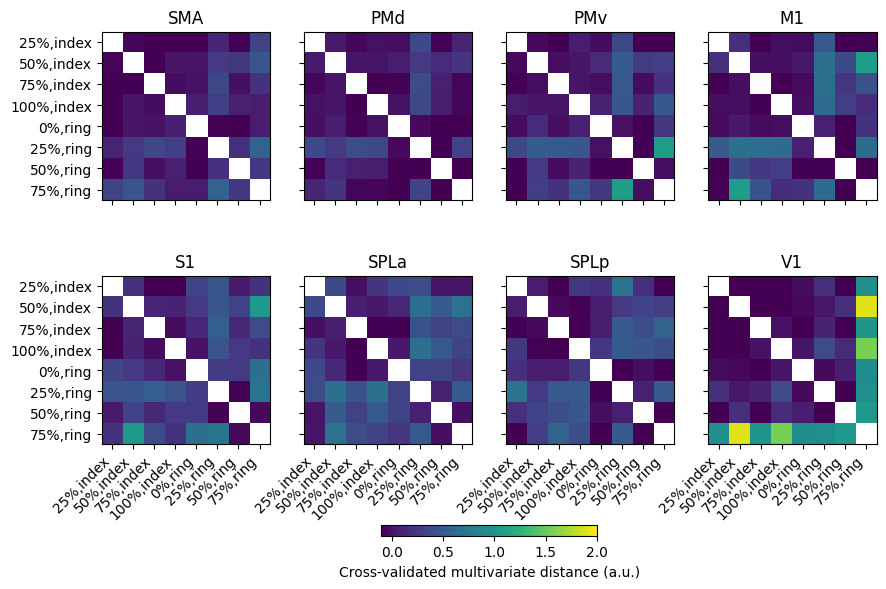

In [35]:
Hem = 'R'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
r = 0
glm = 12
vmin, vmax = -.1, 2
sn=102

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(10, 7))

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    print(f'plotting...glm{glm}.{Hem}.{roi}.hdf5')

    rdms = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}',f'glm{glm}.{Hem}.{roi}.hdf5'))
    rdms = rdms.subset_pattern(by='conds', value=['25%,index', '50%,index', '75%,index', '100%,index',
                                                  '0%,ring', '25%,ring', '50%,ring', '75%,ring',])
    
    cax = rsa.vis.show_rdm_panel(
            rdms, axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[i, j].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
    
    # axs[i, j].axhline(0, color='k', ls='-', lw=.8)
    # axs[i, j].axvline(0, color='k', ls='-', lw=.8)
    r += 1
        
cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'participant:subj{sn}, hemisphere:{Hem}')

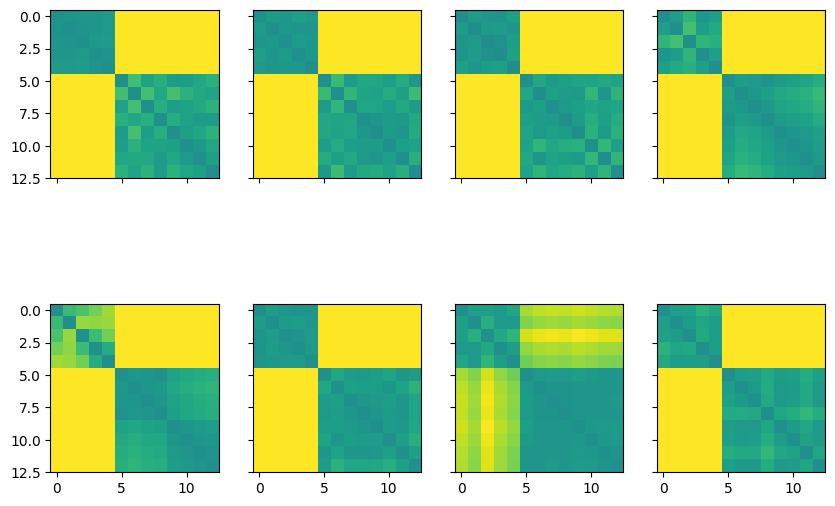

In [5]:
experiment = 'smp2'

rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

sn = 104
Hem = 'L'
glm = 12

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(10, 7))

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    cos = calc_G_cosine(experiment=experiment, sn=sn, Hem=Hem, roi=roi, glm=glm)
    
    cax = axs[row, col].imshow(cos, cmap='viridis', vmin=-1, vmax=1)



Fitting Subj 0 model 0
Fitting Subj 0 model 1
Fitting Subj 0 model 2
Fitting Subj 0 model 3


<Axes: xlabel='model', ylabel='Log Bayes Factor'>

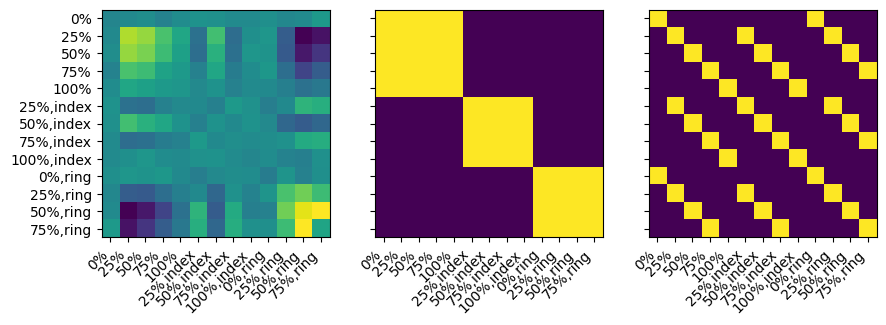

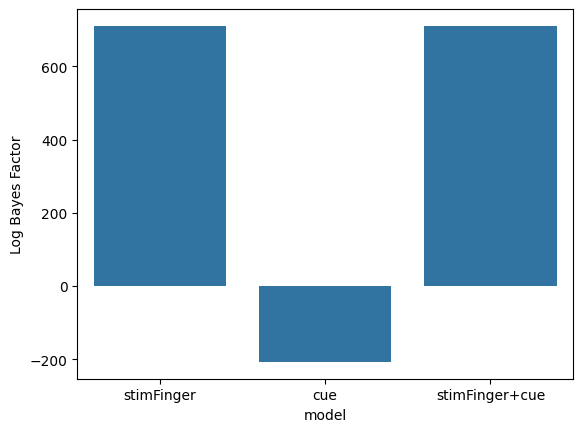

In [20]:
import PcmPy as pcm

experiment = 'smp2'
sn = 102
Hem = 'L'
glm = 12
roi = 'PMd'

Z_stimFinger = np.zeros((13, 3))
Z_stimFinger[0:5, 0] = 1
Z_stimFinger[5:9, 1] = 1
Z_stimFinger[9:13, 2] = 1

Z_cue = np.zeros((13, 5))
Z_cue[[0,9], 0] = 1
Z_cue[[1,5,10], 1] = 1
Z_cue[[2,6,11], 2] = 1
Z_cue[[3,7,12], 3] = 1
Z_cue[[4,8], 4] = 1

reginfo = pd.read_csv(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'subj{sn}_reginfo.tsv'), sep='\t')

betas = np.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'ROI.{Hem}.{roi}.beta.npy'))
res = np.load(os.path.join(gl.baseDir, experiment, f'glm{glm}', f'subj{sn}', f'ROI.{Hem}.{roi}.res.npy'))

betas_prewhitened = betas / res

cond_vec = reginfo.name.str.replace(" ", "").map(gl.regressor_mapping)
part_vec = reginfo.run

obs_des = {'cond_vec': cond_vec,
           'part_vec': part_vec}

Y = pcm.dataset.Dataset(betas_prewhitened, obs_descriptors=obs_des)

G_hat,_ = pcm.est_G_crossval(Y.measurements, Y.obs_descriptors['cond_vec'], Y.obs_descriptors['part_vec'], X=pcm.matrix.indicator(Y.obs_descriptors['part_vec']))

vmin = G_hat.min()
vmax = G_hat.max()

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(10, 7))

axs[0].imshow(G_hat,vmin=vmin,vmax=vmax)
axs[1].imshow(Z_stimFinger @ Z_stimFinger.T)
axs[2].imshow(Z_cue @ Z_cue.T)

for ax in axs:
    ax.set_xticks(np.arange(G_hat.shape[0]))
    ax.set_yticks(np.arange(G_hat.shape[1]))
    ax.set_xticklabels(gl.regressor_mapping.keys(), rotation=45, ha='right')
    ax.set_yticklabels(gl.regressor_mapping.keys(),  ha='right')
    
M = []
M.append(pcm.FixedModel('null',np.eye(13)))
M.append(pcm.FixedModel('stimFinger', Z_stimFinger @ Z_stimFinger.T))
M.append(pcm.FixedModel('cue', Z_cue @ Z_cue.T))
M.append(pcm.ComponentModel('stimFinger+cue',np.array([Z_stimFinger @ Z_stimFinger.T,Z_cue @ Z_cue.T])))

T_in, theta_in = pcm.fit_model_individ(Y,M,fit_scale = True, verbose = True)

_, ax = plt.subplots()

plt.sca(ax)
pcm.model_plot(T_in.likelihood, null_model='null')
